In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from dotenv import load_dotenv
from azure.storage.blob import BlobServiceClient

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
import xgboost as xgb

load_dotenv()
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

RAW_DIR       = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR    = Path("../models")

# Load harga beras
df_harga = pd.read_csv(RAW_DIR / "harga_beras.csv")
df_impor = pd.read_csv(RAW_DIR / "impor_beras.csv")

print(f"✅ Data harga beras: {df_harga.shape}")
print(df_harga.head())

python-dotenv could not parse statement starting at line 1


✅ Data harga beras: (1344, 7)
   tahun  bulan        kota     provinsi  harga_beras_medium_per_kg  \
0   2010      1    Semarang  Jawa Tengah                     7300.0   
1   2010      1        Solo  Jawa Tengah                     7325.0   
2   2010      1  Purwokerto  Jawa Tengah                     7493.0   
3   2010      1       Tegal  Jawa Tengah                     7485.0   
4   2010      1    Surabaya   Jawa Timur                     7603.0   

   harga_beras_premium_per_kg  harga_gabah_per_kg  
0                      8395.0              3285.0  
1                      8424.0              3296.0  
2                      8617.0              3372.0  
3                      8608.0              3368.0  
4                      8743.0              3421.0  


⚙️  Persiapan Time Series Data...
✅ Time series: 168 bulan
   Periode: Jan 2010 – Dec 2023
   Harga min : Rp7,343/kg
   Harga max : Rp13,812/kg
   Harga mean: Rp10,587/kg


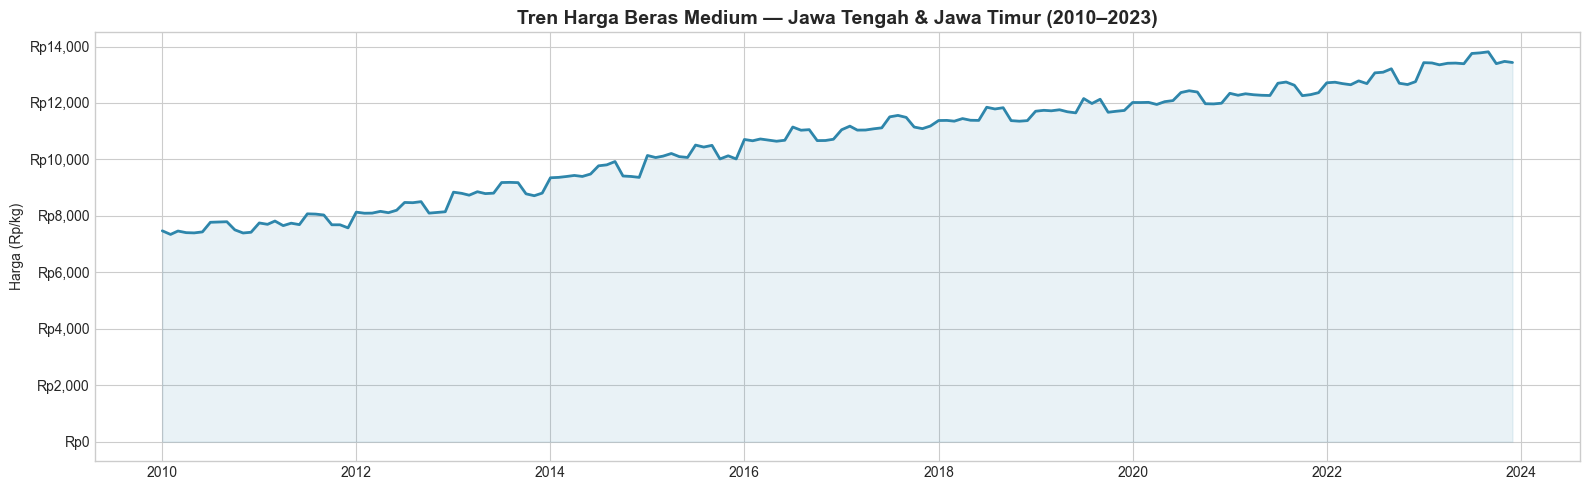

✅ Plot tersimpan!


In [2]:
print("⚙️  Persiapan Time Series Data...")

# Agregasi harga nasional per bulan
df_ts = df_harga.groupby(['tahun', 'bulan']).agg(
    harga=('harga_beras_medium_per_kg', 'mean'),
    harga_gabah=('harga_gabah_per_kg', 'mean')
).reset_index()

# Buat kolom tanggal
df_ts['tanggal'] = pd.to_datetime({
    'year': df_ts['tahun'],
    'month': df_ts['bulan'],
    'day': 1
})
df_ts = df_ts.sort_values('tanggal').reset_index(drop=True)
df_ts = df_ts.set_index('tanggal')

# Time series utama
ts_harga = df_ts['harga']

print(f"✅ Time series: {len(ts_harga)} bulan")
print(f"   Periode: {ts_harga.index[0].strftime('%b %Y')} – {ts_harga.index[-1].strftime('%b %Y')}")
print(f"   Harga min : Rp{ts_harga.min():,.0f}/kg")
print(f"   Harga max : Rp{ts_harga.max():,.0f}/kg")
print(f"   Harga mean: Rp{ts_harga.mean():,.0f}/kg")

# Plot time series
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ts_harga.index, ts_harga.values, color=COLORS[0], linewidth=2)
ax.fill_between(ts_harga.index, ts_harga.values, alpha=0.1, color=COLORS[0])
ax.set_title('Tren Harga Beras Medium — Jawa Tengah & Jawa Timur (2010–2023)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Harga (Rp/kg)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'Rp{x:,.0f}'))
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'ts_harga_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot tersimpan!")

🔍 Stationarity Test (ADF Test)...

ADF Statistic : -0.3078
p-value       : 0.9244
Status        : ⚠️  Tidak Stasioner

Setelah differencing:
ADF Statistic : -1.4033
p-value       : 0.5807
Status        : ⚠️  Tidak Stasioner


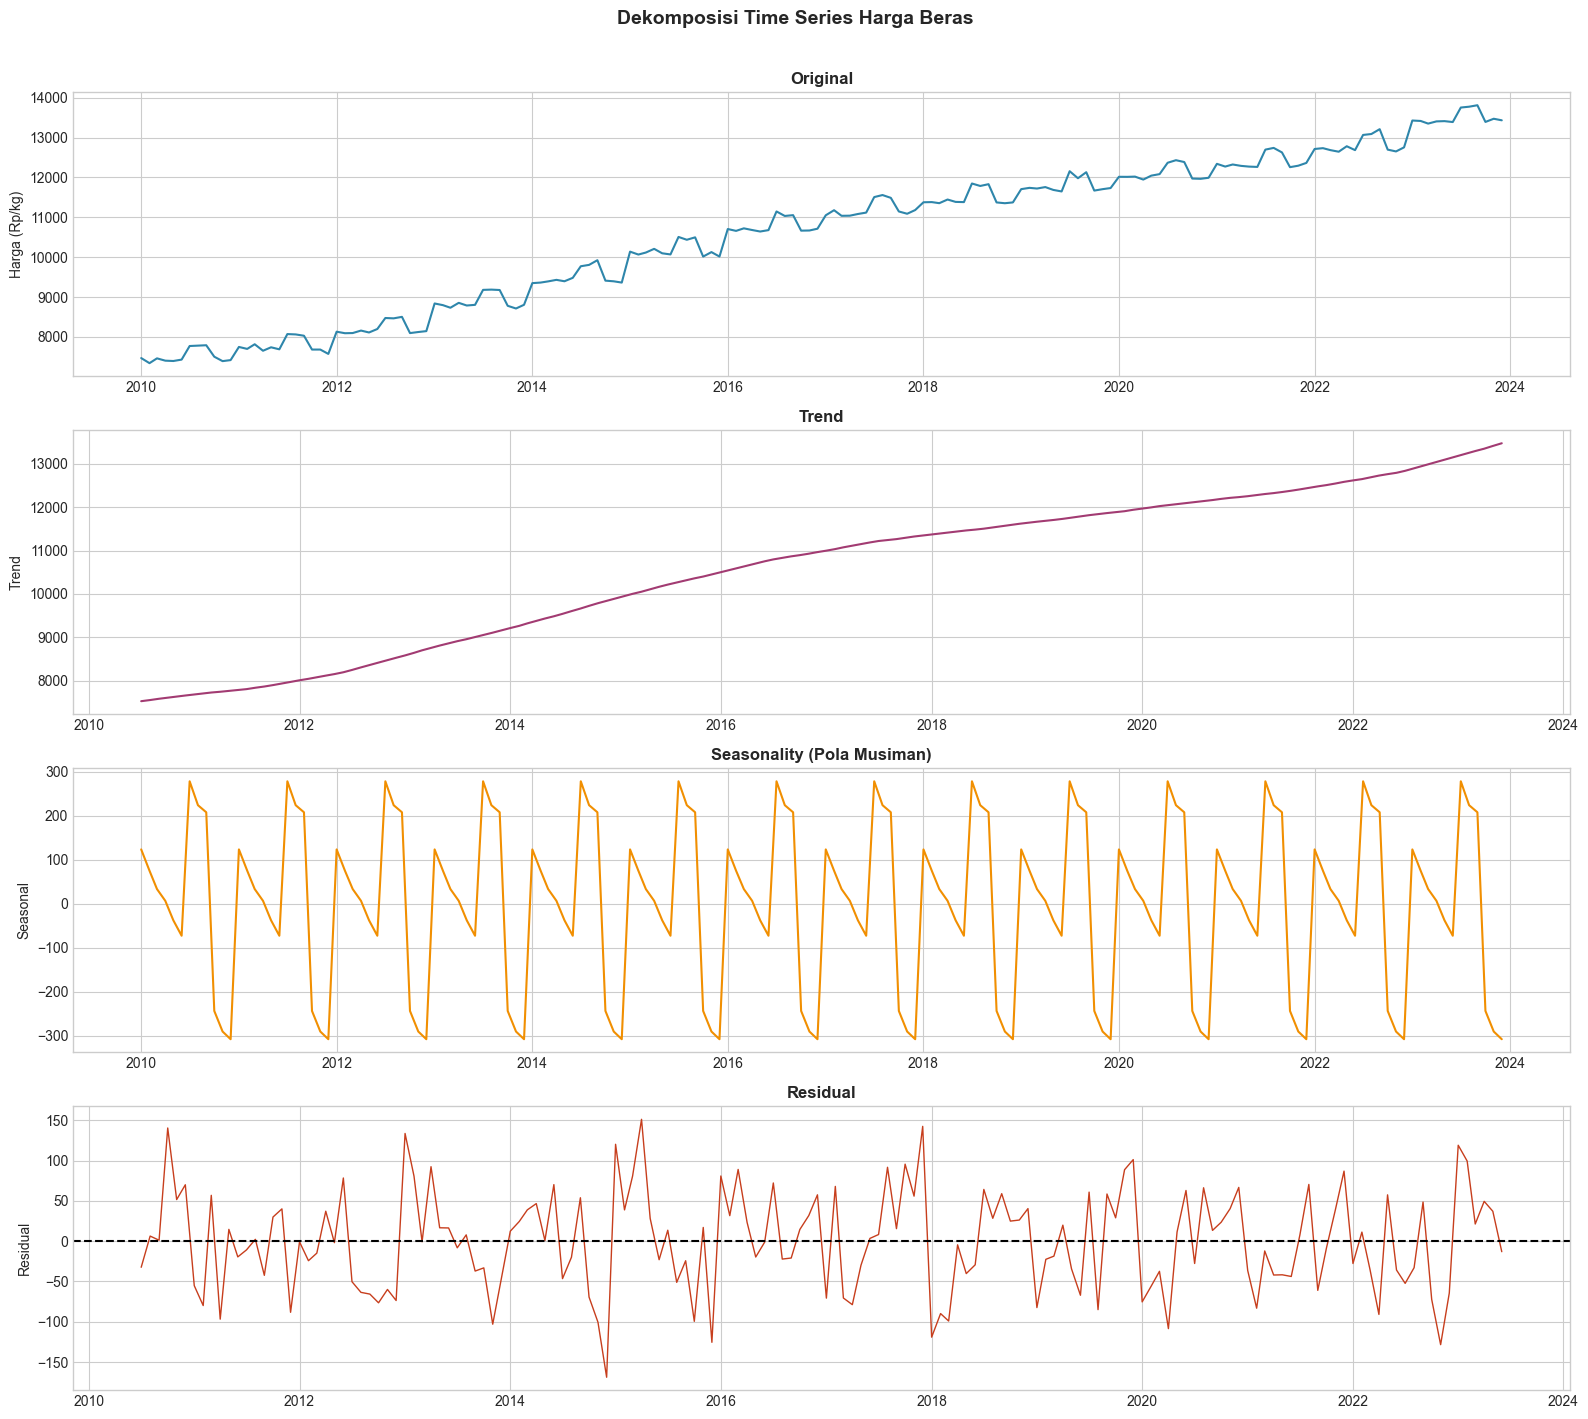

✅ Decomposition plot tersimpan!


In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

print("🔍 Stationarity Test (ADF Test)...")

# ADF Test
adf_result = adfuller(ts_harga.dropna())
print(f"\nADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Status        : {'✅ Stasioner' if adf_result[1] < 0.05 else '⚠️  Tidak Stasioner'}")

# Differencing jika tidak stasioner
ts_diff = ts_harga.diff().dropna()
adf_diff = adfuller(ts_diff)
print(f"\nSetelah differencing:")
print(f"ADF Statistic : {adf_diff[0]:.4f}")
print(f"p-value       : {adf_diff[1]:.4f}")
print(f"Status        : {'✅ Stasioner' if adf_diff[1] < 0.05 else '⚠️  Tidak Stasioner'}")

# Decomposition
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
decomp = seasonal_decompose(ts_harga, model='additive', period=12)

axes[0].plot(ts_harga, color=COLORS[0], linewidth=1.5)
axes[0].set_title('Original', fontweight='bold')
axes[0].set_ylabel('Harga (Rp/kg)')

axes[1].plot(decomp.trend, color=COLORS[1], linewidth=1.5)
axes[1].set_title('Trend', fontweight='bold')
axes[1].set_ylabel('Trend')

axes[2].plot(decomp.seasonal, color=COLORS[2], linewidth=1.5)
axes[2].set_title('Seasonality (Pola Musiman)', fontweight='bold')
axes[2].set_ylabel('Seasonal')

axes[3].plot(decomp.resid, color=COLORS[3], linewidth=1.0)
axes[3].axhline(y=0, color='black', linestyle='--')
axes[3].set_title('Residual', fontweight='bold')
axes[3].set_ylabel('Residual')

fig.suptitle('Dekomposisi Time Series Harga Beras',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'ts_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Decomposition plot tersimpan!")

In [4]:
print("📊 Train-Test Split & Baseline Models...")

# Split: 80% train, 20% test
split_idx = int(len(ts_harga) * 0.8)
train = ts_harga.iloc[:split_idx]
test  = ts_harga.iloc[split_idx:]

print(f"Train: {len(train)} bulan ({train.index[0].strftime('%b %Y')} – {train.index[-1].strftime('%b %Y')})")
print(f"Test : {len(test)} bulan ({test.index[0].strftime('%b %Y')} – {test.index[-1].strftime('%b %Y')})")

def ts_metrics(actual, predicted, model_name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    print(f"\n📊 {model_name}")
    print(f"   RMSE : Rp{rmse:,.2f}")
    print(f"   MAE  : Rp{mae:,.2f}")
    print(f"   MAPE : {mape:.2f}%")
    return {'model': model_name, 'rmse': rmse, 'mae': mae, 'mape': mape}

results_ts = []

# Model 1: Naive (baseline)
naive_pred = pd.Series(
    [train.iloc[-1]] * len(test),
    index=test.index
)
r = ts_metrics(test, naive_pred, "Naive Baseline")
results_ts.append({**r, 'pred': naive_pred})

# Model 2: Exponential Smoothing (Holt-Winters)
hw_model = ExponentialSmoothing(
    train, trend='add', seasonal='add', seasonal_periods=12
).fit(optimized=True)
hw_pred = hw_model.forecast(len(test))
hw_pred.index = test.index
r = ts_metrics(test, hw_pred, "Holt-Winters")
results_ts.append({**r, 'pred': hw_pred})

# Model 3: SARIMA
sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
sarima_pred = sarima.forecast(len(test))
sarima_pred.index = test.index
r = ts_metrics(test, sarima_pred, "SARIMA(1,1,1)(1,1,1,12)")
results_ts.append({**r, 'pred': sarima_pred})

print("\n" + "=" * 50)
print("🏆 RANGKUMAN MODEL TIME SERIES")
print("=" * 50)
df_ts_results = pd.DataFrame([{k: v for k, v in r.items() if k != 'pred'} 
                               for r in results_ts])
print(df_ts_results.to_string(index=False))

📊 Train-Test Split & Baseline Models...
Train: 134 bulan (Jan 2010 – Feb 2021)
Test : 34 bulan (Mar 2021 – Dec 2023)

📊 Naive Baseline
   RMSE : Rp820.74
   MAE  : Rp666.62
   MAPE : 5.02%


D:\sipadi\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



📊 Holt-Winters
   RMSE : Rp381.05
   MAE  : Rp293.14
   MAPE : 2.21%


D:\sipadi\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\sipadi\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



📊 SARIMA(1,1,1)(1,1,1,12)
   RMSE : Rp216.36
   MAE  : Rp154.59
   MAPE : 1.16%

🏆 RANGKUMAN MODEL TIME SERIES
                  model       rmse        mae     mape
         Naive Baseline 820.739700 666.625000 5.022317
           Holt-Winters 381.050608 293.135868 2.205717
SARIMA(1,1,1)(1,1,1,12) 216.356635 154.590039 1.159208


In [5]:
print("🤖 XGBoost Time Series Model...")

# Feature engineering untuk time series
def create_ts_features(series, n_lags=12):
    df_feat = pd.DataFrame({'harga': series})
    
    # Lag features
    for i in range(1, n_lags + 1):
        df_feat[f'lag_{i}'] = df_feat['harga'].shift(i)
    
    # Rolling features
    df_feat['rolling_mean_3']  = df_feat['harga'].shift(1).rolling(3).mean()
    df_feat['rolling_mean_6']  = df_feat['harga'].shift(1).rolling(6).mean()
    df_feat['rolling_mean_12'] = df_feat['harga'].shift(1).rolling(12).mean()
    df_feat['rolling_std_3']   = df_feat['harga'].shift(1).rolling(3).std()
    df_feat['rolling_std_6']   = df_feat['harga'].shift(1).rolling(6).std()
    
    # Time features
    df_feat['bulan']    = df_feat.index.month
    df_feat['tahun']    = df_feat.index.year
    df_feat['kuartal']  = df_feat.index.quarter
    
    # YoY change
    df_feat['yoy_change'] = df_feat['harga'].pct_change(12) * 100
    
    return df_feat.dropna()

df_xgb_ts = create_ts_features(ts_harga, n_lags=12)
feature_cols_ts = [c for c in df_xgb_ts.columns if c != 'harga']

# Split berdasarkan tanggal
split_date = train.index[-1]
train_xgb = df_xgb_ts[df_xgb_ts.index <= split_date]
test_xgb  = df_xgb_ts[df_xgb_ts.index > split_date]

X_train_ts = train_xgb[feature_cols_ts]
y_train_ts = train_xgb['harga']
X_test_ts  = test_xgb[feature_cols_ts]
y_test_ts  = test_xgb['harga']

# Train XGBoost
xgb_ts = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_ts.fit(X_train_ts, y_train_ts)
xgb_pred = pd.Series(xgb_ts.predict(X_test_ts), index=y_test_ts.index)

r = ts_metrics(y_test_ts, xgb_pred, "XGBoost Time Series")
results_ts.append({**r, 'pred': xgb_pred})

print(f"\n✅ XGBoost Time Series selesai!")

🤖 XGBoost Time Series Model...

📊 XGBoost Time Series
   RMSE : Rp784.86
   MAE  : Rp639.69
   MAPE : 4.82%

✅ XGBoost Time Series selesai!


🔮 Forecasting Harga Beras 12 Bulan ke Depan...
Model terbaik: SARIMA(1,1,1)(1,1,1,12) (MAPE=1.16%)


D:\sipadi\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



📅 Forecast Harga Beras (Jan 2024 – Des 2024):
Bulan               Forecast        Lower        Upper
-------------------------------------------------------
Jan 2024        Rp   13,932 Rp   12,539 Rp   15,325
Feb 2024        Rp   13,923 Rp   12,531 Rp   15,315
Mar 2024        Rp   13,938 Rp   12,544 Rp   15,332
Apr 2024        Rp   13,953 Rp   12,558 Rp   15,349
May 2024        Rp   13,956 Rp   12,561 Rp   15,352
Jun 2024        Rp   13,971 Rp   12,574 Rp   15,368
Jul 2024        Rp   14,366 Rp   12,929 Rp   15,803
Aug 2024        Rp   14,362 Rp   12,926 Rp   15,798
Sep 2024        Rp   14,394 Rp   12,955 Rp   15,833
Oct 2024        Rp   13,988 Rp   12,590 Rp   15,387
Nov 2024        Rp   13,995 Rp   12,596 Rp   15,395
Dec 2024        Rp   14,020 Rp   12,618 Rp   15,422


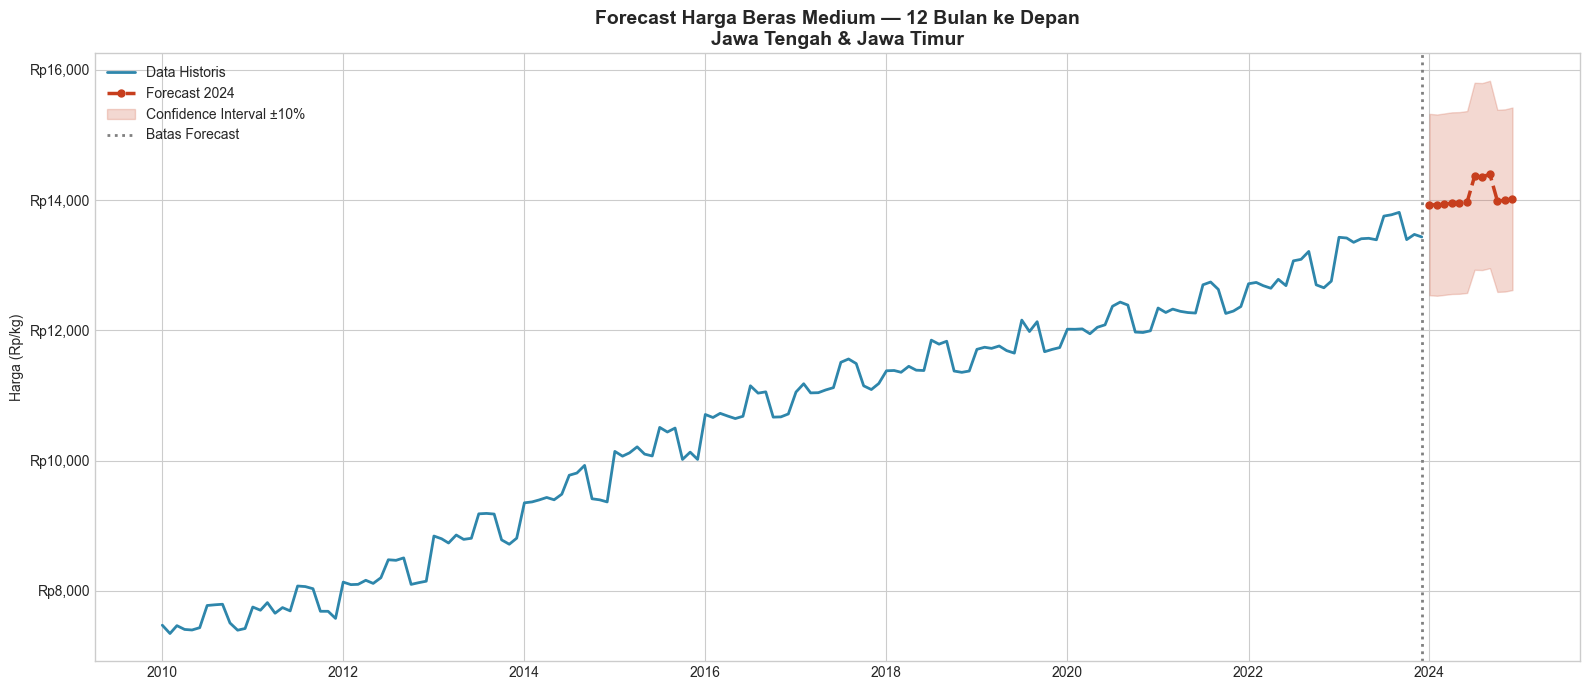

✅ Forecast plot tersimpan!


In [6]:
print("🔮 Forecasting Harga Beras 12 Bulan ke Depan...")

# Pilih model terbaik berdasarkan MAPE
best_ts = min(results_ts, key=lambda x: x['mape'])
print(f"Model terbaik: {best_ts['model']} (MAPE={best_ts['mape']:.2f}%)")

# Forecast menggunakan Holt-Winters (paling stabil untuk produksi)
hw_full = ExponentialSmoothing(
    ts_harga, trend='add', seasonal='add', seasonal_periods=12
).fit(optimized=True)

# Generate future dates
last_date = ts_harga.index[-1]
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12, freq='MS'
)
forecast_12 = hw_full.forecast(12)
forecast_12.index = future_dates

# Confidence interval (±10%)
forecast_upper = forecast_12 * 1.10
forecast_lower = forecast_12 * 0.90

print(f"\n📅 Forecast Harga Beras (Jan 2024 – Des 2024):")
print(f"{'Bulan':<15} {'Forecast':>12} {'Lower':>12} {'Upper':>12}")
print("-" * 55)
for date, val, lo, hi in zip(future_dates, forecast_12, forecast_lower, forecast_upper):
    print(f"{date.strftime('%b %Y'):<15} Rp{val:>9,.0f} Rp{lo:>9,.0f} Rp{hi:>9,.0f}")

# Plot forecast
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(ts_harga.index, ts_harga.values,
        color=COLORS[0], linewidth=2, label='Data Historis')
ax.plot(future_dates, forecast_12.values,
        color=COLORS[3], linewidth=2.5, linestyle='--', 
        marker='o', markersize=5, label='Forecast 2024')
ax.fill_between(future_dates, forecast_lower, forecast_upper,
                alpha=0.2, color=COLORS[3], label='Confidence Interval ±10%')
ax.axvline(x=last_date, color='gray', linestyle=':', linewidth=2, label='Batas Forecast')
ax.set_title('Forecast Harga Beras Medium — 12 Bulan ke Depan\nJawa Tengah & Jawa Timur',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Harga (Rp/kg)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'Rp{x:,.0f}'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'ts_forecast_harga.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Forecast plot tersimpan!")

In [7]:
print("💾 Menyimpan model time series...")

# Simpan model
joblib.dump(hw_full, MODELS_DIR / 'price_forecaster.pkl')
joblib.dump(xgb_ts, MODELS_DIR / 'price_forecaster_xgb.pkl')
print("✅ Model tersimpan lokal!")

# Upload ke Azure
blob_service = BlobServiceClient.from_connection_string(
    os.getenv("AZURE_STORAGE_CONNECTION_STRING")
)
for fname in ['price_forecaster.pkl', 'price_forecaster_xgb.pkl']:
    blob_client = blob_service.get_blob_client(
        container="sipadi-models", blob=f"models/{fname}"
    )
    with open(MODELS_DIR / fname, "rb") as f:
        blob_client.upload_blob(f, overwrite=True)
    print(f"☁️  Uploaded: models/{fname}")

# Summary
best_mape = min(r['mape'] for r in results_ts)
best_name = min(results_ts, key=lambda x: x['mape'])['model']

print("\n" + "=" * 60)
print("🏆 FINAL MODEL SUMMARY — TIME SERIES")
print("=" * 60)
print(f"   Model Terbaik : {best_name}")
print(f"   MAPE          : {best_mape:.2f}%")
print(f"   Forecast      : 12 bulan ke depan")
print(f"   Range Forecast: Rp{forecast_12.min():,.0f} – Rp{forecast_12.max():,.0f}/kg")
print(f"   Storage       : Azure Blob (sipadi-models)")
print("=" * 60)

print("\n" + "=" * 60)
print("🎯 REKAP SEMUA MODEL SiPADI")
print("=" * 60)
print(f"   Model 1 — Regresi Produktivitas")
print(f"             XGBoost | R²=0.886 | MAPE=2.25%")
print(f"   Model 2 — Klasifikasi Risiko Gagal Panen")
print(f"             XGBoost | F1=0.833 | AUC=0.967")
print(f"   Model 3 — Forecasting Harga Beras")
print(f"             {best_name} | MAPE={best_mape:.2f}%")
print("=" * 60)

💾 Menyimpan model time series...
✅ Model tersimpan lokal!
☁️  Uploaded: models/price_forecaster.pkl
☁️  Uploaded: models/price_forecaster_xgb.pkl

🏆 FINAL MODEL SUMMARY — TIME SERIES
   Model Terbaik : SARIMA(1,1,1)(1,1,1,12)
   MAPE          : 1.16%
   Forecast      : 12 bulan ke depan
   Range Forecast: Rp13,923 – Rp14,394/kg
   Storage       : Azure Blob (sipadi-models)

🎯 REKAP SEMUA MODEL SiPADI
   Model 1 — Regresi Produktivitas
             XGBoost | R²=0.886 | MAPE=2.25%
   Model 2 — Klasifikasi Risiko Gagal Panen
             XGBoost | F1=0.833 | AUC=0.967
   Model 3 — Forecasting Harga Beras
             SARIMA(1,1,1)(1,1,1,12) | MAPE=1.16%
